**Final Project- IAF 601**

**Purpose of the project**: Analyzing hospital operations using Python. 

**Datasets used**: Patients, staff, services weekly, staff schedule

**Goals**: Explore patient flow, staffing, and service efficiency to provide actionable insights to improve hospital performance.

**1. Loading Datasets**

In [5]:
#Setup 
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Using zip_path to load/show me all the csv files in the zip folder
zip_path = r"C:\Users\sammy\Desktop\Python\hospital_beds_management_csvs.zip"

#Show files inside the zip folder
with zipfile.ZipFile(zip_path, "r") as z:
    print(z.namelist())                 # shows files inside
    patients = pd.read_csv(z.open("patients.csv"))
    staff= pd.read_csv(z.open("staff.csv"))
    services_weekly= pd.read_csv(z.open("services_weekly.csv"))
    staff_schedule= pd.read_csv(z.open("staff_schedule.csv"))

print("Datasets Loaded!")


['patients.csv', 'services_weekly.csv', 'staff.csv', 'staff_schedule.csv']
Datasets Loaded!


*1.1 Exploring the dataset-Patient*

In [6]:
patients.head()



,patient_id,name,age,arrival_date,departure_date,service,satisfaction
0,PAT-09484753,Richard Rodriguez,24,2025-03-16,2025-03-22,surgery,61
1,PAT-f0644084,Shannon Walker,6,2025-12-13,2025-12-14,surgery,83
2,PAT-ac6162e4,Julia Torres,24,2025-06-29,2025-07-05,general_medicine,83
3,PAT-3dda2bb5,Crystal Johnson,32,2025-10-12,2025-10-23,emergency,81
4,PAT-08591375,Garrett Lin,25,2025-02-18,2025-02-25,ICU,76


In [7]:
staff.head()


,staff_id,staff_name,role,service
0,STF-5ca26577,Allison Hill,doctor,emergency
1,STF-02ae59ca,Noah Rhodes,doctor,emergency
2,STF-d8006e7c,Angie Henderson,doctor,emergency
3,STF-212d8b31,Daniel Wagner,doctor,emergency
4,STF-107a58e4,Cristian Santos,doctor,emergency


In [8]:
services_weekly.head()


,week,month,service,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,event
0,1,1,emergency,32,76,32,44,67,70,none
1,1,1,surgery,45,130,45,85,83,78,flu
2,1,1,general_medicine,37,201,37,164,97,43,flu
3,1,1,ICU,22,31,22,9,84,91,flu
4,2,1,emergency,28,169,28,141,75,64,none


In [9]:
staff_schedule.head()

,week,staff_id,staff_name,role,service,present
0,1,STF-b77cdc60,Allison Hill,doctor,emergency,1
1,2,STF-b77cdc60,Allison Hill,doctor,emergency,1
2,3,STF-b77cdc60,Allison Hill,doctor,emergency,0
3,4,STF-b77cdc60,Allison Hill,doctor,emergency,1
4,5,STF-b77cdc60,Allison Hill,doctor,emergency,1


In [10]:
#Total missing values in all the datasets
datasets = {
    "patients" : patients,
    "staff" : staff, 
    "services_weekly": services_weekly,
    "staff_schedule": staff_schedule
    }

for name, df in datasets.items():
    print(f"\n====Dataset: {name}=====")
#Total Missing values
    total_missing = df.isnull().sum().sum() #is_null looks for true/false values. 1st sum counts missing values in each cell. 2nd sum calculates no of cols with missing values.
    print(f"Total missing values: {total_missing}")

#Missing Values in columns 
missing_by_col = df.isnull().sum() 
print("\nMissing values by column:")
print(missing_by_col[missing_by_col > 0])

#Finding duplicate values in the dataset 
if "patient_id" in df.columns:
    duplicate_ids = df.duplicated('patient_id').sum()
    print(f"\nDuplicate IDs: {duplicate_ids}")
elif "staff_id" in df.columns:
    duplicate_ids = df.duplicated('staff_id').sum()
    print(f"\nDuplicated ids: {duplicate_ids}")
else:
    print("No duplicates")

print("\n------------")


====Dataset: patients=====
Total missing values: 0

====Dataset: staff=====
Total missing values: 0

====Dataset: services_weekly=====
Total missing values: 0

====Dataset: staff_schedule=====
Total missing values: 0

Missing values by column:
Series([], dtype: int64)

Duplicated ids: 6426

------------


### 1.2 Cleaning the datasets

1.2.1 *Patient Dataset Clean-up*

Even though the data set *looks* (no null values, formatting looks good at first glance) clean when we were exploring the data, there needs to be some changes made for more accurate analysis. 

Steps to take: 
1. Arrival date and departure date need to be converted to datetime objects
2. Make sure that age and satisfaction columns have valied numeric fields
3. Satisfaction scores need to be within 1-100 range.
4. Ages cannot be negative numbers or impossible values (0-120)
5. Standardize service names to make data look cleaner and more organized

In [11]:
patients_clean = patients.copy()

#Converting dates to datetime 
patients_clean ['arrival_date'] = pd.to_datetime(patients_clean['arrival_date'], errors = "coerce")
patients_clean ['departure_date'] = pd.to_datetime(patients_clean['departure_date'], errors = "coerce")

#Creating satisfaction range columns (1-10)

patients_clean["satisfaction_1_10"] = (patients_clean["satisfaction"] /10).round()

#Validating satisfaction range columns
invalid_satisfaction = patients_clean[
    (patients_clean["satisfaction_1_10"]<1 )| (patients_clean["satisfaction_1_10"]>10)
]
print ("Invalid satisfaction", len (invalid_satisfaction))

#Validate age

invalid_age = patients_clean[
    (patients_clean["age"] <0) | (patients_clean["age"] >120)]
print("Invalid age", len(invalid_age))

#Standardize service names 
patients_clean["service"] = patients_clean["service"]. str.strip().str.title()

Invalid satisfaction 0
Invalid age 0


In [12]:
#Checking if the satisfaction value range has been rescaled
patients_clean[["satisfaction", "satisfaction_1_10"]].head()


,satisfaction,satisfaction_1_10
0,61,6.0
1,83,8.0
2,83,8.0
3,81,8.0
4,76,8.0


In the cell above, we can see that the satisfction scores have been rescaled to 1-10 range from their orginal range of 1- 100. 

1.2.2 *Cleaning Staff Dataset*

The staff dataset looks clean in the first glance but I will be taking the following steps to make sure there is consistency in the data. 

The steps: 
1. Make sure all the service ids are unique
2. The first initial and last inital of staff is in the upper case. 
3. No duplicates

In [13]:
staff_clean= staff.copy()

#Consistency in text
staff_clean["service"] = staff_clean["service"].str.strip().str.title()
staff_clean["role"] = staff_clean["role"].str.strip().str.title()

#Checking Uniqueness of staff_id
duplicate_ids = staff_clean["staff_id"].duplicated().sum()
print("Duplicate staff IDs:", duplicate_ids)

#Checking for duplicate rows
duplicate_rows= staff_clean.duplicated().sum()
print("Duplicated rows in staff dataset:", duplicate_rows)


Duplicate staff IDs: 0
Duplicated rows in staff dataset: 0


1.2.3 *Weekly Services Dataset Cleaning*

This dataset contains weekly hospital operations. Here are the cleaning steps:

1. convert numerical columns to numeric types 
2. Validation checks to ensure no negative values exist
3. Make sure beds column is not zero to avoid calculation mistakes. 
4. Make sure service names are formatted consistently (Upper case first letter)


In [14]:
services_weekly_clean = services_weekly.copy()

#Making sure columns are numeric only

numeric_cols = [ 
    "available_beds", 
    "patients_request",
    "patients_admitted",
    "patients_refused",
    "patient_satisfaction",
    "staff_morale"
]

for col in numeric_cols:
    services_weekly_clean[col] = pd.to_numeric(services_weekly_clean [col])

#Checking for negative values
negative_values = (services_weekly_clean [numeric_cols] <0).sum()
print("Negative values per column:", negative_values) 

#No zeros in the columns 
zero_beds = services_weekly_clean[services_weekly_clean["available_beds"]==0]
print("Zero beds:", len (zero_beds))

#Consistent service names
services_weekly_clean["service"] = services_weekly_clean["service"].str.strip().str.title()

Negative values per column: available_beds          0
patients_request        0
patients_admitted       0
patients_refused        0
patient_satisfaction    0
staff_morale            0
dtype: int64
Zero beds: 0


1.2.4 *Cleaning Staff Schedule* 

The staff schedule dataset contains staff attendance. It looks relatively clean but we can perform some more cleaning steps to ensure consistency and accuracy.

Steps: 
1. Make sure that 'present' and 'absent' are in numeric format.
2. Consistency in service and role texts
3. Make sure no staff member repeats in the same week. 

 

In [15]:
staff_schedule_clean = staff_schedule.copy()

#Numeric formatting in present/absent column

staff_schedule_clean["present"] = pd.to_numeric(staff_schedule_clean["present"])

#Standardize text fields
staff_schedule_clean["service"] = staff_schedule_clean["service"].str.strip().str.title()
staff_schedule_clean["role"] = staff_schedule_clean["role"].str.strip().str.title()

#Unique IDs validation 
duplicate_attendance= staff_schedule_clean.duplicated(subset= ["staff_id","week"]).sum()
print ("Duplicate staff/week enteries:", duplicate_attendance)

Duplicate staff/week enteries: 0


**1.2- Summary of Cleaning Section**

In this section, I focused on cleaning all 4 datasets in the hospital zip files. Here is the summary of the following operations done on the files: 

1. Converted date fields to datetime format
2. Ensured numeric operations were correct
3. Ensured consistency in text formats throughout the datasets
4. Validated that all IDs were unique IDs and no duplicate rows were found
5. Ensured no invalid or out-of-range values occured 

## 2. Analysis and Visualizations


*Analysis 1- Patient Satisfaction by Service*

In [34]:
satisfaction_by_service = patients_clean.groupby("service")["satisfaction_1_10"].mean()
satisfaction_by_service
# Python function for re-useable analyses
def average_satisfaction(df):
    return df.groupby("service")["satisfaction_1_10"].mean()

<function matplotlib.pyplot.show(close=None, block=None)>

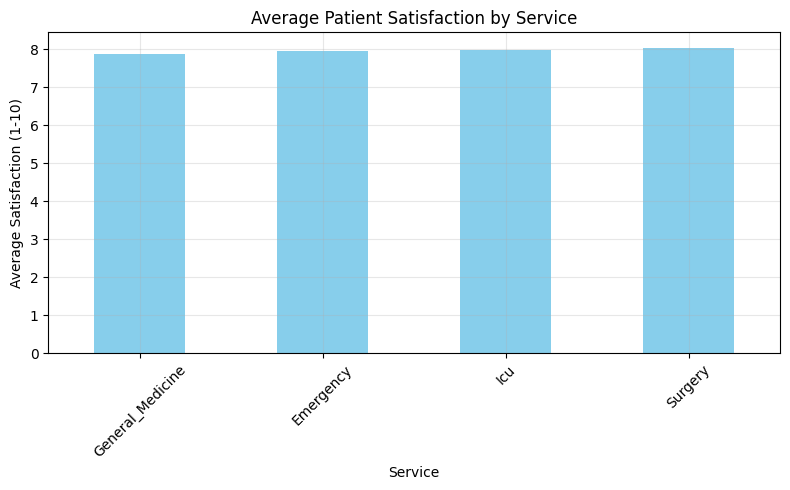

In [17]:
#Plot for Patient Satisfaction by Service 
plt.figure(figsize= (8,5))

satisfaction_by_service.sort_values().plot(kind = "bar", color= "skyblue")

plt.title("Average Patient Satisfaction by Service")
plt.xlabel("Service")
plt.ylabel("Average Satisfaction (1-10)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation =45)
plt.tight_layout()
plt.show


**Patient Satisfaction by Service- Data Analysis**

The bar chart shows the average patient satisfaction scores (scaled 1–10) for the four major hospital services: General Medicine, Emergency, ICU, and Surgery. Overall, satisfaction scores are quite close across all departments, showing that there is generally consistent quality of care in the hospital.

 There are still small but meaningful differences that need to be mentioned:

- **General Medicine** has the lowest average satisfaction (just under 7.9).  
- **Emergency**, **ICU**, and **Surgery** all are slightly higher, around 8.0.

This suggests that patient experiences across departments are consistent for the most part. Still, the slightly lower satisfaction score in General Medicine may be because of the longer wait times, larger number of patirnts, or staffing issues, which can be explored further in the sectiosn of bed occupancy or staff attendance.

These patterns provide a useful baseline for identifying which services may benefit most from targeted improvements in workflow, staffing, or communication with patients.


**Analysis 2- Bed Occupany Rate by Week**

In [35]:
#Bed Occupancy Analysis
services_weekly_clean["occupancy_rate"] = (
    services_weekly_clean ["patients_admitted"]/ services_weekly_clean["available_beds"]
)

#Grouping by week to get overall average occupancy
weekly_occupancy= services_weekly_clean.groupby("week")["occupancy_rate"].mean()
weekly_occupancy

#Python Function for reuseable analysis: 
def add_occupancy_rate(df):
    df["occupancy_rate"] = df["patients_admitted"] / df["available_beds"]
    return df


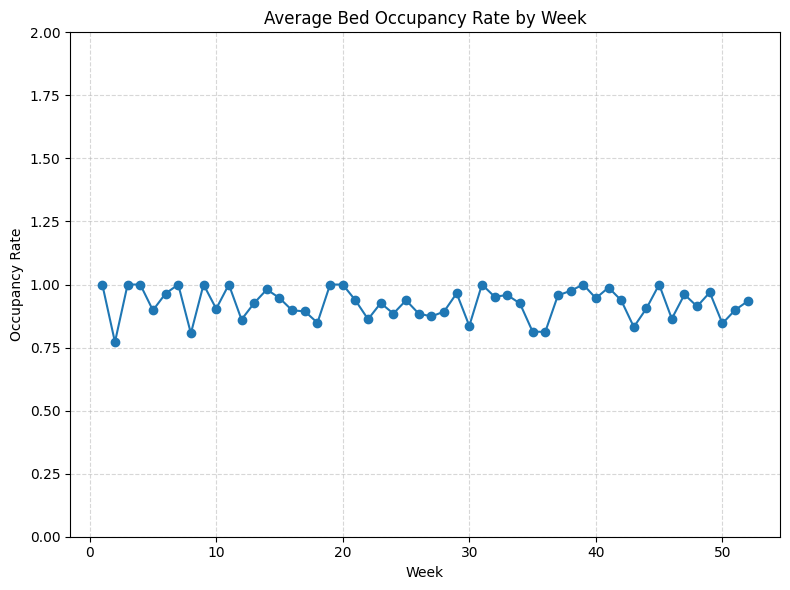

In [30]:
plt.figure(figsize=(8,6))
plt.plot(weekly_occupancy.index, weekly_occupancy.values, marker="o")
plt.title("Average Bed Occupancy Rate by Week")
plt.xlabel("Week")
plt.ylabel("Occupancy Rate")
plt.grid(True, alpha=0.3)
plt.ylim(0, 2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Interpretation: Average Bed Occupancy Rate by Week

The line chart above shows the average bed occupancy rate for each week of the year. Occupancy rates in this chart range between **0.80 and 1.00**, showing that hospital capacity is in heavy demand.

The line chart shows the following trend:

- **Most weeks fall between 90% and 100% occupancy**, telling us that the hospital regularly operates almost to its maximum capacity.
- **A few dips to around 0.80–0.85** may be because of seasonal fluctuations, reduced patient intake, or temporary increases in available beds.
- **Several peaks reach exactly 1.00**, meaning that all available beds were filled during those weeks.

Overall, the hospital experiences **high and consistent occupancy**, with very few variations from week to week. The consistent bed occupancy to 100% can strain operations and reduce staff morale. This pattern shows that there is a need for a efficient strategy for management, increase in staffing, or improvements in patient flow.


**Analysis 3- Patients Requested VS Admitted by Month**


In [38]:

requests_by_month = services_weekly_clean.groupby("month")["patients_request"].sum()
admitted_by_month = services_weekly_clean.groupby("month")["patients_admitted"].sum()




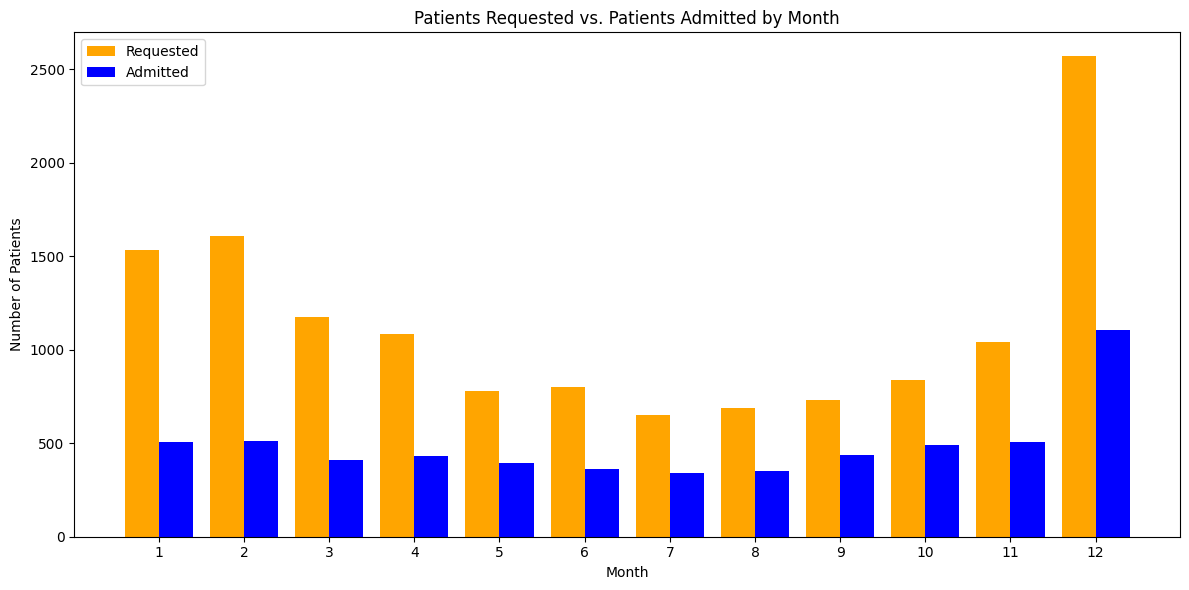

In [40]:
#Visualisation 
months = requests_by_month.index
x = np.arange(len(months))
width = 0.4



plt.figure(figsize=(12,6))

plt.bar(x - width/2, requests_by_month.values, width=width, label="Requested", color="orange")
plt.bar(x + width/2, admitted_by_month.values, width=width, label="Admitted", color="blue")

plt.title("Patients Requested vs. Patients Admitted by Month")
plt.xlabel("Month")
plt.ylabel("Number of Patients")
plt.xticks(x, months)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation: Patients Requested vs. Patients Admitted by Month

This bar chart compares the number of patients who requested services to the number of patients who were actually admitted each month. The orange bars represent patient requests, while the blue bars represent admissions.

Overall, the chart shows that **patient demand is consistently higher than the hospital's capacity to admit**, although the difference is not extremely large. A few key patterns stand out:

- In every month, the **number of patients requesting care is slightly higher** than the number admitted.
- This shows that the hospital is **operating at or near its capacity**, which makes it difficult to admit all requesting patients.
- Combined with the high bed occupancy rates found earlier (often above 90%), these results suggest that **capacity limitations—not lack of demand—are restricting admissions**.
- The gap between requested and admitted patients is relatively consistent across months, meaning that the issue is **system-wide** rather than seasonal.

Overall, this visualization confirms that the hospital experiences **more demand than available resources**, which contributes to high occupancy rates, potential delays, and unmet patient requests.


**Analysis 4- Staff Attendance and Workload Trends**

In [ ]:
#Analysis- Attendance by Service 

attendance_by_service= staff_schedule_clean.groupby("service") ["present"]. mean()
attendance_by_service = attendance_by_service.sort_values (ascending= False)
attendance_by_service

#Python Function of reusuable analysis:
def attendance_by_service(df):
    return df.groupby("service")["present"].mean()

service
Emergency           0.604043
Surgery             0.602308
Icu                 0.601244
General_Medicine    0.589973
Name: present, dtype: float64

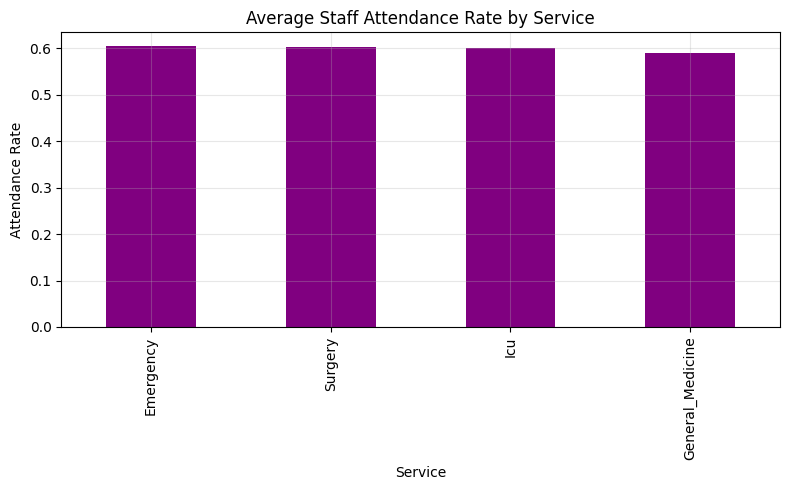

In [23]:
#Visualization 
plt.figure(figsize = (8,5))
attendance_by_service.plot(kind="bar", color="purple")
plt.title ("Average Staff Attendance Rate by Service")
plt.xlabel ("Service")
plt.ylabel ("Attendance Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretation: Average Staff Attendance Rate by Service

The bar chart shows the average weekly staff attendance rate for each hospital service. Attendance scores range from approximately **0.59 to 0.60**, indicating that staff were present for about 59–60% of scheduled shifts across all services.

Interestingly, attendance rates are almost identical across departments:

- **Emergency:** ~0.60  
- **Surgery:** ~0.60  
- **ICU:** ~0.60  
- **General Medicine:** ~0.59  

The lack of variation suggests that staffing challenges are **system-wide** rather than isolated to a single department. This level of attendance may be insufficient during high-demand periods, especially since the hospital’s bed occupancy frequently approaches full capacity.

These results imply that improving staff attendance—or ensuring adequate coverage through scheduling, overtime, or float staff—could help alleviate pressure on services and improve patient throughput and satisfaction.
